# Machine Learning Assignment: Handwritten Digit Classification

**Individual submission:** Alon B. **Last four digits of student ID:** 2607.

## Learning problem and dataset

The goal is to predict which digit, 0–9, appears in a handwritten image. This is supervised, multiclass classification. We use the [MNIST Dataset on Kaggle](https://www.kaggle.com/datasets/hojjatk/mnist-dataset), explicitly suggested in the assignment instructions. It contains 60,000 training images and 10,000 test images, each a 28×28 grayscale matrix with its correct digit label. We preserve the original train/test split and do not repartition these datasets.

We extract normalized intensity histograms, both global and local, and compare their cumulative versions. The learning algorithm is **Gaussian Naive Bayes**, implemented independently using NumPy. The primary evaluation metric is **macro F1**. Configuration selection uses cross-validation within the training set only.

## Connection to course materials

- `L03_image_as_data_basic_features.pdf`: images as matrices on page 94; histograms on pages 95–100; normalized and cumulative histograms on pages 152–153; local histograms on page 155.
- `L07_Supervised_Learning_Flow.pdf`: the Naive Bayes family on pages 26 and 42; smoothing hyperparameters on page 162; grid search on page 171.
- Mention of the Naive Bayes family does not establish that this exact Gaussian implementation was taught. Its formula, independence assumption, and smoothing mechanism are therefore explained explicitly below.

## Evaluation metric

For each digit, precision is the fraction of predictions for that digit that are correct. Recall is the fraction of its actual examples that are identified. `F1 = 2 * precision * recall / (precision + recall)`. Macro F1 is the equally weighted mean of the ten per-class F1 scores, as required for multiclass classification. Accuracy is reported only as a secondary metric; it is not equivalent to macro F1.

## Test-set history and transparency

A pixel-based model was evaluated on the same test set during an earlier draft. Its results are not the results of this histogram model. We introduced histogram features to align with the course materials, and configurations here are selected using training data only. This is another evaluation on a test set previously observed during the project; it must not be described as a never-before-used holdout. We do not retune the configuration in response to its test score.


## Part 1: Setup and dataset loading

We download the public Kaggle files if they are missing, validate their IDX headers and dimensions, and save data checksums for provenance. If the download service is unavailable, download the dataset from Kaggle and place the four IDX files listed in the code in the `data` directory. A fixed random seed makes the cross-validation folds reproducible.

In [1]:
%matplotlib inline
from pathlib import Path
import hashlib
import json
import struct
import urllib.request
import zipfile
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from threadpoolctl import threadpool_limits

ROOT = Path.cwd()
DATA = ROOT / 'data'
RESULTS = ROOT / 'results'
DATA.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)
SEED = 42
threadpool_limits(limits=2)
pd.set_option('display.max_columns', 15)
DATASET_URL = 'https://www.kaggle.com/datasets/hojjatk/mnist-dataset'
FILES = ['train-images-idx3-ubyte', 'train-labels-idx1-ubyte',
         't10k-images-idx3-ubyte', 't10k-labels-idx1-ubyte']
if not all((DATA / name).exists() for name in FILES):
    archive = DATA / 'mnist.zip'
    urllib.request.urlretrieve(
        'https://www.kaggle.com/api/v1/datasets/download/hojjatk/mnist-dataset', archive)
    with zipfile.ZipFile(archive) as z:
        for info in z.infolist():
            name = Path(info.filename).name
            if name in FILES:
                (DATA / name).write_bytes(z.read(info))
    archive.unlink()



Original split: (60000, 28, 28) (10000, 28, 28)
TRAIN first five rows (all 784 pixels are in each row)


,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,...,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,5,0,0,0,0,0,0,...,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,...,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,...,0,0,0,0,0,0,0


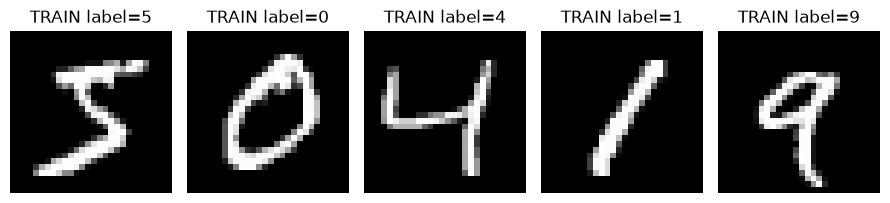

TEST first five rows (all 784 pixels are in each row)


,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,...,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,...,0,0,0,0,0,0,0


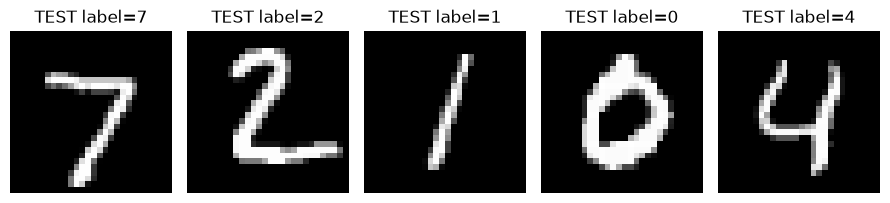

,digit,train_count,test_count
0,0,5923,980
1,1,6742,1135
2,2,5958,1032
3,3,6131,1010
4,4,5842,982
5,5,5421,892
6,6,5918,958
7,7,6265,1028
8,8,5851,974
9,9,5949,1009


In [2]:
def read_images(path):
    raw = path.read_bytes()
    magic, n, h, w = struct.unpack('>IIII', raw[:16])
    if magic != 2051 or len(raw) != 16 + n * h * w:
        raise ValueError('Invalid IDX image file')
    return np.frombuffer(raw, dtype=np.uint8, offset=16).reshape(n, h, w)

def read_labels(path):
    raw = path.read_bytes()
    magic, n = struct.unpack('>II', raw[:8])
    if magic != 2049 or len(raw) != 8 + n:
        raise ValueError('Invalid IDX label file')
    return np.frombuffer(raw, dtype=np.uint8, offset=8)

train_images = read_images(DATA / FILES[0])
y_train = read_labels(DATA / FILES[1])
test_images = read_images(DATA / FILES[2])
y_test = read_labels(DATA / FILES[3])
assert train_images.shape == (60000, 28, 28)
assert test_images.shape == (10000, 28, 28)
assert len(y_train) == len(train_images) and len(y_test) == len(test_images)
manifest = {name: hashlib.sha256((DATA / name).read_bytes()).hexdigest() for name in FILES}
(RESULTS / 'data_sha256.json').write_text(json.dumps(manifest, indent=2))
print('Original split:', train_images.shape, test_images.shape)
for title, images, labels in [('TRAIN', train_images, y_train), ('TEST', test_images, y_test)]:
    print(title, 'first five rows (all 784 pixels are in each row)')
    frame = pd.DataFrame(images[:5].reshape(5, -1), columns=[f'pixel_{i}' for i in range(784)])
    frame.insert(0, 'label', labels[:5])
    display(frame)
    fig, axes = plt.subplots(1, 5, figsize=(9, 2))
    for i, ax in enumerate(axes):
        ax.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'{title} label={labels[i]}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()
class_counts = pd.DataFrame({'digit': range(10), 'train_count': np.bincount(y_train),
                             'test_count': np.bincount(y_test)})
display(class_counts)



## Part 2: Feature engineering from the course

In MNIST, intensity 0 is black and 255 is white. A histogram counts pixels within fixed brightness intervals. With 16 bins, for example, the first bin contains values 0–15 and the second contains 16–31. Dividing counts by the number of pixels in a region gives a discrete distribution over bins whose entries sum to 1. Bin boundaries are fixed rather than fitted using the test set.

A global histogram discards pixel positions. Local histograms divide an image into a grid and compute a histogram for each region, preserving coarse location information. Regions are concatenated in row-major order, left to right and top to bottom. Each regional histogram sums to 1; the concatenated vector sums to the number of regions.

A cumulative histogram takes the running sum within each region. Its last entry is 1, but the sum of all its entries is not necessarily 1. The number of features is `grid_size ** 2 * bins`. Cumulative features are strongly dependent, so they are not necessarily better suited to a naive classifier.

We show the transformation on three examples from each original dataset. The demonstration settings are fixed in advance and are not chosen by inspecting the test examples.

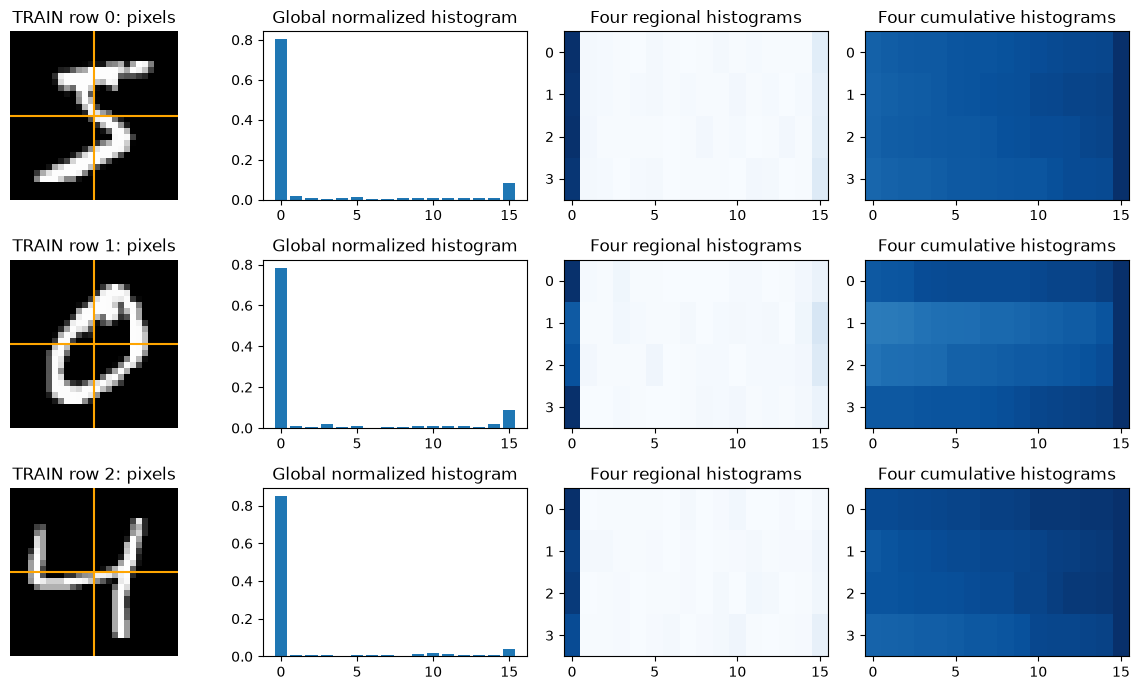

,split,row,pixel_range,global_feature_count,local_feature_count,first_region_values
0,TRAIN,0,"(0, 255)",16,64,"[0.8112, 0.0153, 0.0102, 0.0051, 0.0, 0.0153, ..."
1,TRAIN,1,"(0, 255)",16,64,"[0.8418, 0.0102, 0.0051, 0.0306, 0.0051, 0.005..."
2,TRAIN,2,"(0, 255)",16,64,"[0.898, 0.0, 0.0051, 0.0051, 0.0051, 0.0051, 0..."


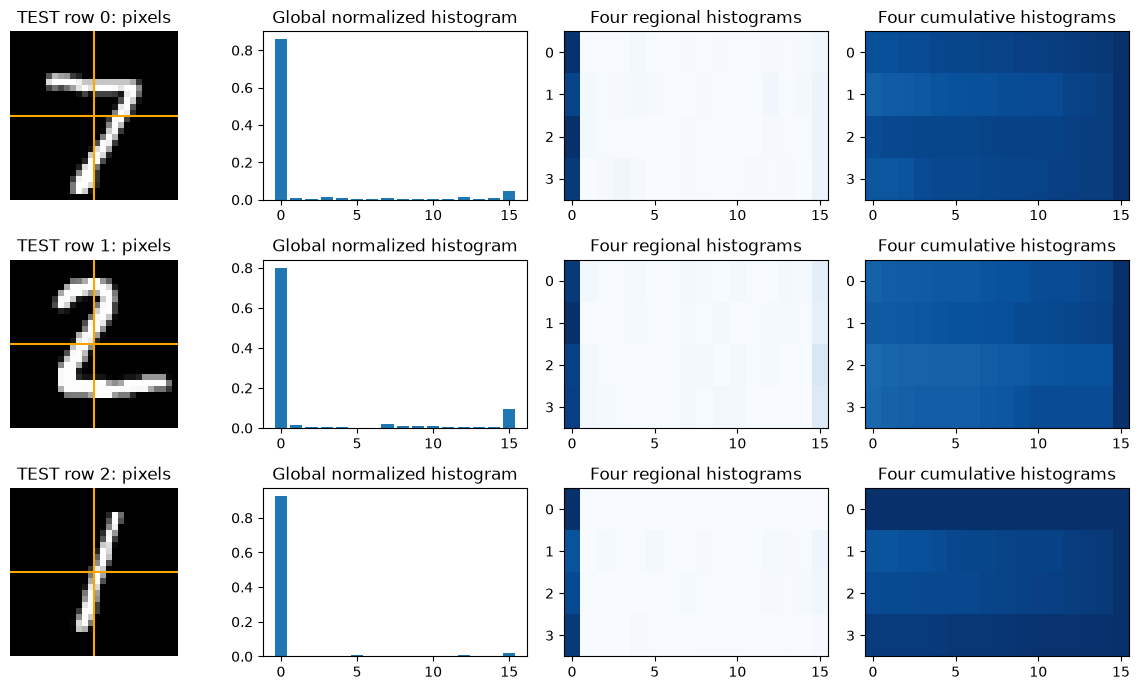

,split,row,pixel_range,global_feature_count,local_feature_count,first_region_values
0,TEST,0,"(0, 255)",16,64,"[0.8776, 0.0051, 0.0051, 0.0051, 0.0153, 0.005..."
1,TEST,1,"(0, 255)",16,64,"[0.8061, 0.0204, 0.0051, 0.0051, 0.0102, 0.0, ..."
2,TEST,2,"(0, 255)",16,64,"[0.9949, 0.0, 0.0, 0.0051, 0.0, 0.0, 0.0, 0.0,..."


In [3]:
def histogram_features(images, bins=16, grid_size=1):
    if bins < 1 or bins > 256 or int(bins) != bins:
        raise ValueError('bins must be an integer from 1 to 256')
    n, h, w = images.shape
    if grid_size < 1 or int(grid_size) != grid_size or h % grid_size or w % grid_size:
        raise ValueError('grid_size must evenly divide image dimensions')
    block_h, block_w = h // grid_size, w // grid_size
    parts = []
    for row in range(grid_size):
        for col in range(grid_size):
            block = images[:, row*block_h:(row+1)*block_h,
                           col*block_w:(col+1)*block_w]
            bin_ids = (block.astype(np.int32) * bins // 256).reshape(n, -1)
            offsets = np.arange(n)[:, None] * bins
            counts = np.bincount((bin_ids + offsets).ravel(), minlength=n*bins).reshape(n, bins)
            parts.append(counts.astype(np.float64) / (block_h * block_w))
    return np.concatenate(parts, axis=1)


def extract_features(images, bins=16, grid_size=2, cumulative=False):
    features = histogram_features(images, bins=bins, grid_size=grid_size)
    if cumulative:
        n = len(images)
        features = features.reshape(n, grid_size**2, bins).cumsum(axis=2).reshape(n, -1)
    return features

for split, images in [('TRAIN', train_images), ('TEST', test_images)]:
    rows = []
    fig, axes = plt.subplots(3, 4, figsize=(12, 7))
    for i in range(3):
        original_image = images[i]
        global_hist = extract_features(images[i:i+1], bins=16, grid_size=1)[0]
        local_hist = extract_features(images[i:i+1], bins=16, grid_size=2)[0].reshape(4, 16)
        cumulative_hist = extract_features(images[i:i+1], bins=16, grid_size=2,
                                           cumulative=True)[0].reshape(4, 16)
        axes[i, 0].imshow(original_image, cmap='gray', vmin=0, vmax=255)
        axes[i, 0].axhline(13.5, color='orange')
        axes[i, 0].axvline(13.5, color='orange')
        axes[i, 0].axis('off')
        axes[i, 0].set_title(f'{split} row {i}: pixels')
        axes[i, 1].bar(range(16), global_hist)
        axes[i, 1].set_title('Global normalized histogram')
        axes[i, 2].imshow(local_hist, aspect='auto', cmap='Blues')
        axes[i, 2].set_title('Four regional histograms')
        axes[i, 3].imshow(cumulative_hist, aspect='auto', cmap='Blues', vmin=0, vmax=1)
        axes[i, 3].set_title('Four cumulative histograms')
        rows.append({'split': split, 'row': i, 'pixel_range': (int(original_image.min()),
                     int(original_image.max())), 'global_feature_count': len(global_hist),
                     'local_feature_count': local_hist.size,
                     'first_region_values': local_hist[0].round(4).tolist()})
    plt.tight_layout()
    plt.show()
    display(pd.DataFrame(rows))


## Part 3: Gaussian Naive Bayes implemented from scratch

`fit` learns class priors, feature means, and feature variances. `predict` computes a score for every class and selects the largest. Each feature is approximated by a Gaussian distribution within a class, and the model assumes features are conditionally independent given the class. This is an approximation: normalized histogram bins are dependent because their sum is fixed, and cumulative features have even stronger dependence.

For image vector `x` and class `c`, the score is:

```text
log(prior[c]) - 0.5 * sum_j(log(2*pi*variance[c,j]) + (x[j]-mean[c,j])**2/variance[c,j])
```

Logarithms avoid numerical underflow from multiplying tiny likelihoods. The code expands the squared term and uses matrix products to compute the same expression efficiently.

**Hyperparameter: `var_smoothing`.** We add this value multiplied by the largest training feature variance to every class-feature variance, with a tiny positive minimum. This avoids division by zero and reduces the influence of nearly constant features. The scale is calculated only from the training portion of each fold. Tied class scores select the first class in sorted digit order; test results are not used to break ties.

In [4]:
class GaussianNaiveBayes:
    """No sklearn estimator: training and prediction use only NumPy."""
    def __init__(self, var_smoothing=0.01):
        if var_smoothing <= 0:
            raise ValueError('var_smoothing must be positive')
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y)
        if X.ndim != 2 or len(X) != len(y) or not len(X):
            raise ValueError('Expected nonempty aligned X and y')
        self.classes_, counts = np.unique(y, return_counts=True)
        self.priors_ = counts / counts.sum()
        self.means_ = np.stack([X[y == c].mean(axis=0) for c in self.classes_])
        variances = np.stack([X[y == c].var(axis=0) for c in self.classes_])
        # A relative floor prevents division by zero in constant features.
        self.epsilon_ = max(self.var_smoothing * X.var(axis=0).max(), 1e-12)
        self.variances_ = variances + self.epsilon_
        return self

    def joint_log_scores(self, X, batch_size=1000):
        X = np.asarray(X, dtype=np.float64)
        if X.ndim != 2 or X.shape[1] != self.means_.shape[1]:
            raise ValueError('Feature dimensions do not match the trained model')
        inv = 1.0 / self.variances_
        constant = np.log(self.priors_) - 0.5 * (
            np.log(2 * np.pi * self.variances_).sum(axis=1)
            + (self.means_ ** 2 * inv).sum(axis=1))
        scores = np.empty((len(X), len(self.classes_)))
        for start in range(0, len(X), batch_size):
            block = X[start:start+batch_size]
            scores[start:start+batch_size] = (
                -0.5 * (block ** 2) @ inv.T
                + block @ (self.means_ * inv).T + constant)
        return scores

    def predict(self, X):
        return self.classes_[self.joint_log_scores(X).argmax(axis=1)]



### Independent correctness checks

We compare the fast score calculation with the direct Gaussian formula, verify predictions on separated synthetic classes, and check the zero-variance case. We also compare our histograms with NumPy's implementation, verify regional normalization, and check that bin boundaries handle intensities 0 and 255 correctly.

In [5]:
tiny_X = np.array([[0., 0.], [0.1, 0.2], [0.8, 0.9], [1., 1.]])
tiny_y = np.array([0, 0, 1, 1])
tiny = GaussianNaiveBayes(0.01).fit(tiny_X, tiny_y)
queries = np.array([[0.05, 0.1], [0.9, 0.95]])
direct_scores = np.stack([
    np.log(tiny.priors_[c]) - 0.5 * (
        np.log(2*np.pi*tiny.variances_[c])
        + (queries-tiny.means_[c])**2/tiny.variances_[c]).sum(axis=1)
    for c in range(2)], axis=1)
np.testing.assert_allclose(tiny.joint_log_scores(queries), direct_scores, atol=1e-10)
np.testing.assert_array_equal(tiny.predict(queries), [0, 1])
constant = GaussianNaiveBayes().fit(np.ones((4, 2)), tiny_y)
assert np.isfinite(constant.joint_log_scores(np.ones((2, 2)))).all()
print('Manual Gaussian score, predictions, and zero-variance checks passed.')


for bins in (8, 16):
    for grid in (1, 2, 4):
        images = train_images[:3]
        features = extract_features(images, bins, grid, False)
        regions = features.reshape(3, grid**2, bins)
        np.testing.assert_allclose(regions.sum(axis=2), 1)
        height = 28 // grid
        for i in range(3):
            for row in range(grid):
                for col in range(grid):
                    pixels = images[i, row*height:(row+1)*height, col*height:(col+1)*height]
                    expected = np.histogram(pixels, bins=bins, range=(0, 256))[0] / pixels.size
                    np.testing.assert_allclose(regions[i, row*grid+col], expected)
        cumulative = extract_features(images, bins, grid, True).reshape(3, grid**2, bins)
        np.testing.assert_allclose(cumulative[:, :, -1], 1)
        assert (np.diff(cumulative, axis=2) >= -1e-12).all()
edge_image = np.tile(np.array([0, 255], dtype=np.uint8), (28, 14))[None]
edge_hist = extract_features(edge_image, bins=16, grid_size=1)[0]
assert edge_hist[0] == 0.5 and edge_hist[-1] == 0.5
print('Histogram reference, normalization, cumulative, and bin-edge checks passed.')


Manual Gaussian score, predictions, and zero-variance checks passed.
Histogram reference, normalization, cumulative, and bin-edge checks passed.


## Extension 6a: Exhaustive grid search with cross-validation

We evaluate **every** combination of these four settings:

| Setting | Values | Meaning |
|---|---|---|
| `bins` | 8, 16 | Number of brightness intervals per histogram |
| `grid_size` | 1, 2, 4 | One global region, four regions, or sixteen regions |
| `cumulative` | False, True | Ordinary or cumulative histogram |
| `var_smoothing` | 0.001, 0.01, 0.1 | Strength of variance smoothing in the model |

This Cartesian product contains `2 * 3 * 2 * 3 = 36` configurations. Each is evaluated with five folds: **180 training fits**. The folds are equal in size and preserve approximately the same class proportions. Four folds are used for training and one for validation, rotating through all five.

We select by the mean validation macro F1 across the five folds. The table includes every fold score, the mean, and the standard deviation; the winning configuration is also displayed separately. Ties are resolved by a fixed ordering of configuration values.

Histogram extraction uses fixed boundaries and learns no statistics, so it can be computed once per feature configuration. The model and its smoothing scale are learned separately within each fold's training portion. We do not resample data or alter the original test set.

In [6]:
folds = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
             .split(train_images, y_train))
records = []
for bins, grid, cumulative in product((8, 16), (1, 2, 4), (False, True)):
    X = extract_features(train_images, bins=bins, grid_size=grid, cumulative=cumulative)
    for smoothing in (0.001, 0.01, 0.1):
        scores = []
        for train_idx, valid_idx in folds:
            candidate = GaussianNaiveBayes(smoothing).fit(X[train_idx], y_train[train_idx])
            predictions = candidate.predict(X[valid_idx])
            scores.append(f1_score(y_train[valid_idx], predictions, average='macro', zero_division=0))
        records.append({'bins': bins, 'grid_size': grid, 'cumulative': cumulative,
                        'var_smoothing': smoothing, 'feature_count': X.shape[1],
                        **{f'fold_{i+1}_f1': score for i, score in enumerate(scores)},
                        'mean_macro_f1': float(np.mean(scores)),
                        'std_macro_f1': float(np.std(scores))})
        print(f'bins={bins}, grid={grid}, cumulative={cumulative}, '
              f'smoothing={smoothing}: CV macro F1={np.mean(scores):.4f}', flush=True)
    del X
grid_results = pd.DataFrame(records).sort_values(
    ['mean_macro_f1', 'grid_size', 'bins', 'cumulative', 'var_smoothing'],
    ascending=[False, True, True, True, True], kind='stable').reset_index(drop=True)
assert len(grid_results) == 36
grid_results.to_csv(RESULTS / 'grid_search.csv', index=False)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(grid_results)
best = grid_results.iloc[0]
best_params = {'bins': int(best['bins']), 'grid_size': int(best['grid_size']),
               'cumulative': bool(best['cumulative'])}
best_smoothing = float(best['var_smoothing'])
print('BEST TRAINING CV CONFIGURATION:')
display(grid_results.iloc[[0]])


bins=8, grid=1, cumulative=False, smoothing=0.001: CV macro F1=0.2352


bins=8, grid=1, cumulative=False, smoothing=0.01: CV macro F1=0.2153


bins=8, grid=1, cumulative=False, smoothing=0.1: CV macro F1=0.1789


bins=8, grid=1, cumulative=True, smoothing=0.001: CV macro F1=0.1618


bins=8, grid=1, cumulative=True, smoothing=0.01: CV macro F1=0.1617


...

bins=16, grid=4, cumulative=True, smoothing=0.01: CV macro F1=0.6080


bins=16, grid=4, cumulative=True, smoothing=0.1: CV macro F1=0.6283


,bins,grid_size,cumulative,var_smoothing,feature_count,fold_1_f1,fold_2_f1,fold_3_f1,fold_4_f1,fold_5_f1,mean_macro_f1,std_macro_f1
0,16,4,True,0.100,256,0.625875,0.633808,0.627474,0.625380,0.628758,0.628259,0.003021
1,8,4,True,0.100,128,0.624175,0.632747,0.625963,0.623876,0.628766,0.627105,0.003314
2,8,4,False,0.100,128,0.619699,0.625982,0.620861,0.618666,0.618451,0.620732,0.002761
3,16,4,False,0.100,256,0.617580,0.622279,0.617390,0.617820,0.614040,0.617822,0.002623
4,16,4,True,0.010,256,0.608183,0.607224,0.607541,0.608715,0.608552,0.608043,0.000575
5,8,4,True,0.010,128,0.605721,0.604985,0.604455,0.607238,0.608591,0.606198,0.001520
6,8,4,False,0.010,128,0.605416,0.608190,0.605368,0.603820,0.604721,0.605503,0.001462
7,16,4,False,0.010,256,0.591330,0.591402,0.586683,0.586701,0.593476,0.589919,0.002745
8,16,4,True,0.001,256,0.571035,0.572015,0.569123,0.573099,0.572704,0.571595,0.001421
9,8,4,True,0.001,128,0.567920,0.571082,0.567941,0.570906,0.572255,0.570021,0.001769


BEST TRAINING CV CONFIGURATION:


,bins,grid_size,cumulative,var_smoothing,feature_count,fold_1_f1,fold_2_f1,fold_3_f1,fold_4_f1,fold_5_f1,mean_macro_f1,std_macro_f1
0,16,4,True,0.1,256,0.625875,0.633808,0.627474,0.62538,0.628758,0.628259,0.003021


## Part 4: Final training on the entire training set

After selecting the configuration using validation only, we show its features for three training examples and fit a **new model** on all 60,000 original training examples. We do not adjust the configuration based on the test set.

In [7]:
X_train = extract_features(train_images, **best_params)
display(pd.DataFrame(X_train[:3], columns=[f'feature_{i}' for i in range(X_train.shape[1])]))
print('Selected feature parameters:', best_params, 'var_smoothing:', best_smoothing)
print('Final training feature matrix:', X_train.shape)
final_model = GaussianNaiveBayes(best_smoothing).fit(X_train, y_train)
np.savez_compressed(RESULTS / 'trained_model.npz', classes=final_model.classes_,
                    priors=final_model.priors_, means=final_model.means_,
                    variances=final_model.variances_, bins=best_params['bins'],
                    grid_size=best_params['grid_size'], cumulative=best_params['cumulative'],
                    var_smoothing=best_smoothing)
del X_train


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,...,feature_249,feature_250,feature_251,feature_252,feature_253,feature_254,feature_255
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,0.959184,0.959184,0.959184,0.979592,0.979592,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Selected feature parameters: {'bins': 16, 'grid_size': 4, 'cumulative': True} var_smoothing: 0.1
Final training feature matrix: (60000, 256)


## Part 5: Test predictions and quality evaluation

We apply **exactly the selected feature transformation** to the original test set. We display the features of its first three examples, its first five predictions, and metrics over all 10,000 examples. In the confusion matrix, rows are true digits and columns are predicted digits. The diagonal contains correct predictions; off-diagonal entries represent errors.

This is the final evaluation of the histogram model. As disclosed above, this test set was previously observed during the pixel-model draft. The current settings were nevertheless selected using training cross-validation only.

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,...,feature_249,feature_250,feature_251,feature_252,feature_253,feature_254,feature_255
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.938776,0.959184,0.959184,0.959184,0.959184,0.959184,1.0
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0


Final test feature matrix: (10000, 256)


,test_row,true_digit,predicted_digit,correct
0,0,7,7,True
1,1,2,2,True
2,2,1,1,True
3,3,0,8,False
4,4,4,4,True


FINAL test macro F1: 0.6380221264191511
Secondary accuracy: 0.6415


,precision,recall,f1-score,support
0,0.750720,0.531633,0.622461,980.0000
1,0.533777,0.918943,0.675299,1135.0000
2,0.919866,0.533915,0.675659,1032.0000
3,0.745685,0.641584,0.689729,1010.0000
4,0.567308,0.540733,0.553702,982.0000
5,0.744681,0.392377,0.513950,892.0000
6,0.817149,0.825678,0.821391,958.0000
7,0.721640,0.736381,0.728936,1028.0000
8,0.477080,0.577002,0.522305,974.0000
9,0.515199,0.655104,0.576789,1009.0000


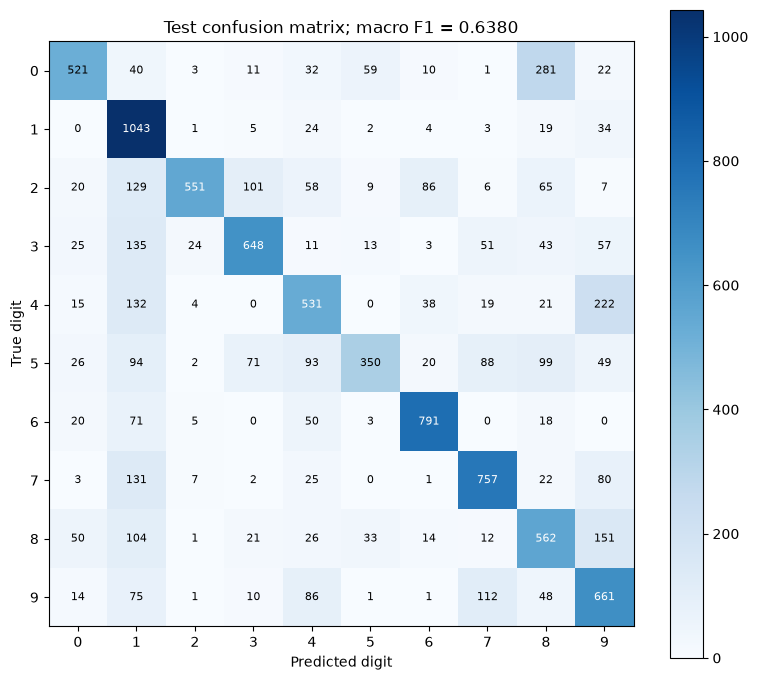

In [8]:
X_test = extract_features(test_images, **best_params)
display(pd.DataFrame(X_test[:3], columns=[f'feature_{i}' for i in range(X_test.shape[1])]))
print('Final test feature matrix:', X_test.shape)
y_pred = final_model.predict(X_test)
test_macro_f1 = float(f1_score(y_test, y_pred, average='macro', zero_division=0))
first_five = pd.DataFrame({'test_row': range(5), 'true_digit': y_test[:5],
                          'predicted_digit': y_pred[:5], 'correct': y_test[:5] == y_pred[:5]})
display(first_five)
print('FINAL test macro F1:', test_macro_f1)
print('Secondary accuracy:', float((y_pred == y_test).mean()))
report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True, zero_division=0)).T
display(report)
report.to_csv(RESULTS / 'classification_report.csv')
first_five.to_csv(RESULTS / 'first_five_predictions.csv', index=False)
pd.DataFrame({'true_digit': y_test, 'predicted_digit': y_pred}).to_csv(
    RESULTS / 'test_predictions.csv', index=False)
metrics = {'train_count': len(y_train), 'test_count': len(y_test),
           'feature_type': 'normalized_local_histograms', **best_params,
           'var_smoothing': best_smoothing, 'feature_count': X_test.shape[1],
           'best_cv_macro_f1': float(best['mean_macro_f1']),
           'cv_std_macro_f1': float(best['std_macro_f1']),
           'test_macro_f1': test_macro_f1, 'accuracy': float((y_pred == y_test).mean()),
           'seed': SEED, 'configurations': len(records), 'cv_fits': len(records)*5,
           'test_previously_evaluated_in_pixel_draft': True}
(RESULTS / 'metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')
cm = confusion_matrix(y_test, y_pred, labels=range(10))
pd.DataFrame(cm, index=range(10), columns=range(10)).to_csv(RESULTS / 'confusion_matrix.csv')
fig, ax = plt.subplots(figsize=(8, 7))
plot = ax.imshow(cm, cmap='Blues')
for r, c in product(range(10), repeat=2):
    ax.text(c, r, str(cm[r, c]), ha='center', va='center', fontsize=8,
            color='white' if cm[r, c] > cm.max()/2 else 'black')
ax.set(xticks=range(10), yticks=range(10), xlabel='Predicted digit', ylabel='True digit',
       title=f'Test confusion matrix; macro F1 = {test_macro_f1:.4f}')
fig.colorbar(plot, ax=ax)
plt.tight_layout()
plt.savefig(RESULTS / 'confusion_matrix.png', dpi=150)
plt.show()


## Extension 6c: Explain the model and one prediction

The trained model stores the mean of each feature for each class. We visualize these by region and brightness bin. They are **mean histogram features**, not reconstructed images of digits.

For a fixed test example, row 0, we compare the winning class with the runner-up. Each feature contributes the difference between its class log likelihoods: a positive value favors the winner, and a negative value favors the alternative. The sum of these contributions plus the log prior ratio must equal the total class-score margin; we verify this numerically.

The map explains the model's arithmetic. It is not a causal explanation or a calibrated confidence probability. Histograms discard exact positions within regions, and conditional independence is only an approximation; these are important limitations.

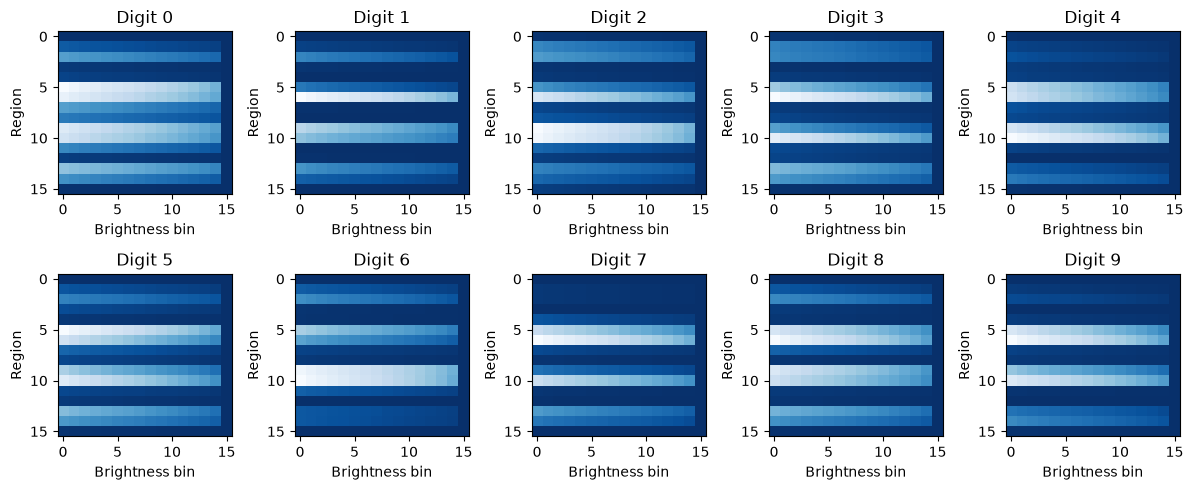

,digit,joint_log_score
0,7,338.892593
1,9,308.399645
2,1,297.793517
3,3,286.720397
4,5,284.507795
5,4,264.040949
6,8,258.721505
7,0,224.229575
8,2,219.606624
9,6,183.029816


Explanation score margin: 30.492948860538142 ; prior contribution: 0.05175545014226294


,feature_index,region,brightness_bin,feature_value,winner_minus_runner_log_evidence
145,145,9,1,0.979592,1.824886
144,144,9,0,0.959184,1.799326
146,146,9,2,0.979592,1.726427
147,147,9,3,0.979592,1.638806
148,148,9,4,0.979592,1.571696
149,149,9,5,0.979592,1.486023
150,150,9,6,0.979592,1.404468
151,151,9,7,0.979592,1.331123
152,152,9,8,0.979592,1.244149
153,153,9,9,0.979592,1.156590


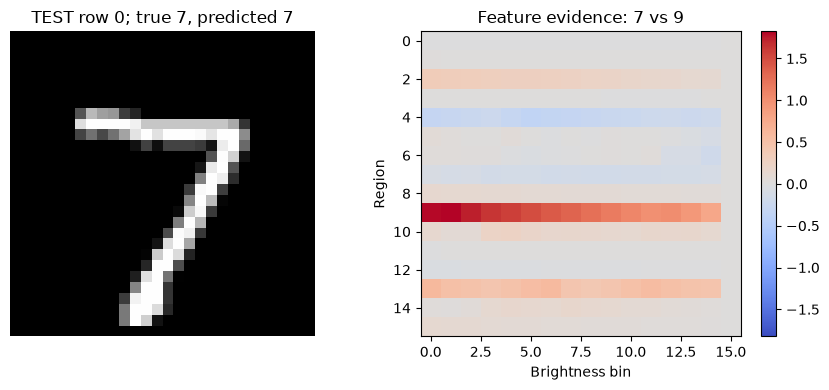

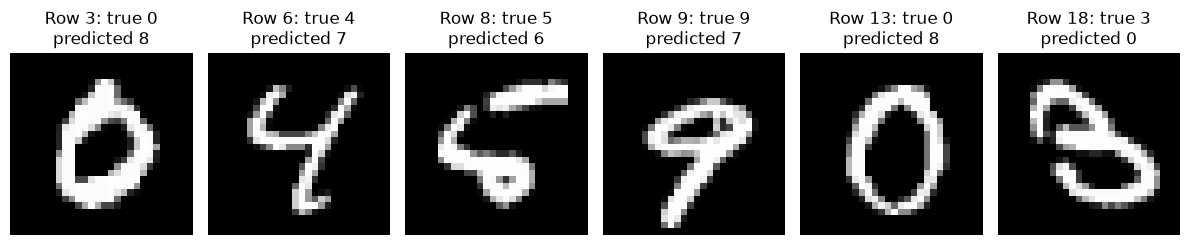

Largest test confusion: 0 predicted as 8 count: 281


In [9]:
regions = best_params['grid_size'] ** 2
bins = best_params['bins']
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for c, ax in enumerate(axes.flat):
    ax.imshow(final_model.means_[c].reshape(regions, bins), cmap='Blues', aspect='auto')
    ax.set_title(f'Digit {final_model.classes_[c]}')
    ax.set_xlabel('Brightness bin')
    ax.set_ylabel('Region')
plt.tight_layout()
plt.savefig(RESULTS / 'learned_histogram_means.png', dpi=150)
plt.show()
sample_index = 0
scores = final_model.joint_log_scores(X_test[sample_index:sample_index+1])[0]
rank = np.argsort(scores, kind='stable')[::-1]
display(pd.DataFrame({'digit': final_model.classes_[rank], 'joint_log_score': scores[rank]}))
winner, runner = rank[:2]
x = X_test[sample_index]
def feature_log_likelihood(class_idx):
    return -0.5 * (np.log(2*np.pi*final_model.variances_[class_idx])
                   + (x-final_model.means_[class_idx])**2/final_model.variances_[class_idx])
contribution = feature_log_likelihood(winner) - feature_log_likelihood(runner)
prior_contribution = np.log(final_model.priors_[winner]/final_model.priors_[runner])
margin = contribution.sum() + prior_contribution
np.testing.assert_allclose(margin, scores[winner]-scores[runner], rtol=1e-8, atol=1e-8)
explanation = pd.DataFrame({'feature_index': range(len(x)),
                            'region': np.repeat(range(regions), bins),
                            'brightness_bin': np.tile(range(bins), regions),
                            'feature_value': x, 'winner_minus_runner_log_evidence': contribution})
explanation.to_csv(RESULTS / 'prediction_explanation.csv', index=False)
print('Explanation score margin:', margin, '; prior contribution:', prior_contribution)
display(explanation.iloc[np.argsort(np.abs(contribution))[::-1][:10]])
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(test_images[sample_index], cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f'TEST row 0; true {y_test[0]}, predicted {final_model.classes_[winner]}')
axes[0].axis('off')
v = max(np.abs(contribution).max(), 1e-12)
plot = axes[1].imshow(contribution.reshape(regions, bins), aspect='auto', cmap='coolwarm',
                       vmin=-v, vmax=v)
axes[1].set_title(f'Feature evidence: {final_model.classes_[winner]} vs {final_model.classes_[runner]}')
axes[1].set_xlabel('Brightness bin')
axes[1].set_ylabel('Region')
fig.colorbar(plot, ax=axes[1])
plt.tight_layout()
plt.savefig(RESULTS / 'prediction_explanation.png', dpi=150)
plt.show()
errors = np.flatnonzero(y_test != y_pred)[:6]
if len(errors):
    fig, axes = plt.subplots(1, len(errors), figsize=(12, 2.5))
    for index, ax in zip(errors, np.atleast_1d(axes)):
        ax.imshow(test_images[index], cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'Row {index}: true {y_test[index]}\npredicted {y_pred[index]}')
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(RESULTS / 'example_errors.png', dpi=150)
    plt.show()
off_diagonal = cm.copy()
np.fill_diagonal(off_diagonal, 0)
true_digit, confused_digit = np.unravel_index(off_diagonal.argmax(), off_diagonal.shape)
print('Largest test confusion:', true_digit, 'predicted as', confused_digit,
      'count:', int(off_diagonal[true_digit, confused_digit]))


## Observed results

The selected configuration uses **16 brightness bins**, a **4×4 regional grid**, **cumulative** histograms, and variance smoothing of **0.1**. Each image has **256 features**. Mean validation macro F1 is **0.6283**, with a fold standard deviation of **0.0030**.

Final test **macro F1 is 0.6380**, and **accuracy is 64.15%**. The most frequent confusion is **281 images of digit 0 predicted as digit 8**. Metrics and errors are reported as measured, without changing settings in response to the test outcome.

Local histograms preserve coarse location but lose exact positions within a region. The classifier also assumes independence between dependent features. These are possible explanations for the limited performance; the notebook documents the process and limitations, reflecting the assignment's emphasis on understanding rather than only obtaining a high score.

The earlier pixel-model draft achieved test macro F1 of 0.8123. That was a different representation and is not this model's score. It is mentioned to disclose the history of test-set use and is not used to retune the histogram configuration.